In [14]:
import torch, random, shutil, os, numpy as np, torch.nn as nn

ar = np.array([[1,2,3],[4,5,6]])
ar = torch.from_numpy(ar)
ar = ar.flatten()
print(ar)

tensor([1, 2, 3, 4, 5, 6])


cpu
y shape: torch.Size([10, 23])
torch.Size([20, 23])
y shape: torch.Size([10, 23])
torch.Size([20, 23])
y shape: torch.Size([10, 23])
torch.Size([20, 23])
y shape: torch.Size([10, 23])
torch.Size([20, 23])
y shape: torch.Size([10, 23])
torch.Size([20, 23])
y shape: torch.Size([10, 23])
torch.Size([20, 23])
y shape: torch.Size([10, 23])
torch.Size([20, 23])
y shape: torch.Size([10, 23])
torch.Size([20, 23])
y shape: torch.Size([10, 23])
torch.Size([20, 23])
y shape: torch.Size([10, 23])
torch.Size([20, 23])
y shape: torch.Size([10, 23])
torch.Size([20, 23])
y shape: torch.Size([10, 23])
torch.Size([20, 23])
y shape: torch.Size([10, 23])
torch.Size([20, 23])
y shape: torch.Size([10, 23])
torch.Size([20, 23])
y shape: torch.Size([10, 23])
torch.Size([20, 23])
y shape: torch.Size([10, 23])
torch.Size([20, 23])
y shape: torch.Size([10, 23])
torch.Size([20, 23])
y shape: torch.Size([10, 23])
torch.Size([20, 23])
y shape: torch.Size([10, 23])
torch.Size([20, 23])
y shape: torch.Size([10, 23

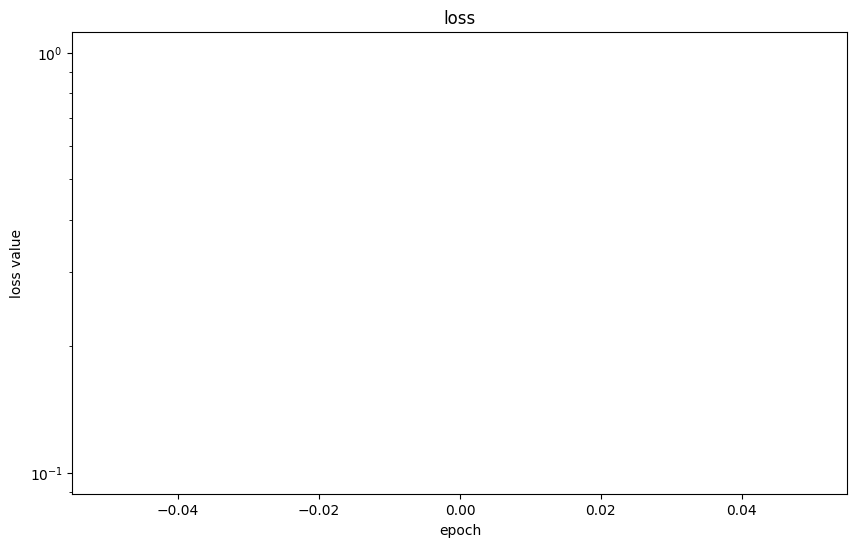

In [15]:
# %% ### Import ###
import torch, random, shutil, os, numpy as np, torch.nn as nn
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d
from scipy import integrate
import shutil
from ema_pytorch import EMA
import matplotlib
import seaborn as sns
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import time
import random
from sklearn.metrics import r2_score

start_time = time.time()


# %% ### Functions ###
class CustomDataset(Dataset):
    """Custom dataset for loading images.
    Attributes: data: dataset (dtype: torch.Tensor)"""

    def __init__(self, dataset):
        """Initialize the dataset.
        Args: dataset: dataset to load (dtype: np.array)"""
        self.data = torch.Tensor(dataset)

    def __len__(self):
        """Return the length of the dataset."""
        return len(self.data)

    def __getitem__(self, idx):
        """Get the item at the index idx.
        Args: idx: index of the item to get (dtype: int)
        Returns: x: item at the index idx (dtype: torch.Tensor)"""
        x = self.data[idx]
        return x

class VE:
    def __init__(self, sigma_max, sigma_min):
        self.sigma = sigma_max

    def _drift(self, x, t):
        return torch.zeros(x.shape)

    def _marginal_prob_mean(self, t):
        return torch.ones((1,))

    def _marginal_prob_std(self, t):
        return torch.sqrt((self.sigma**(2 * t) - 1.) / 2. / np.log(self.sigma))

    def _diffusion_coeff(self, t):
        return self.sigma**t
    
    
class score_edm(torch.nn.Module):
    def __init__(self, device, x_dim=1, y_dim=1 ,width=256, depth=2, activation=nn.ReLU):
        super().__init__()
        
        self.width = width
        self.depth = depth
        self.activation = activation()
        self.dim = x_dim+y_dim

        net = []
        net.append(nn.Linear(self.dim+4,self.width))
        net.append(self.activation)
        for _ in range(self.depth):
            net.append(nn.Linear(self.width,self.width))
            net.append(self.activation)
        net.append(nn.Linear(self.width,x_dim))
        self.net = nn.Sequential(*net).to(device=device)
        
    def forward(self, x, y, t, mode=None):
        t = t.squeeze()
        embed = [t - 0.5, torch.cos(2*np.pi*t), torch.sin(2*np.pi*t), -torch.cos(4*np.pi*t)]
        embed = torch.stack(embed, dim=-1) 

        x_in = torch.cat([x, y, embed], dim=-1)
        
        score = self.net(x_in).to(torch.float32)
        return score
    
def loss_func(net, X, y, schedule):
    t = torch.rand([X.shape[0], 1], device=X.device)
    noise = torch.randn_like(X) 
    mean = (schedule._marginal_prob_mean(t)).to(X.device)
    std  = (schedule._marginal_prob_std(t)).to(X.device)
    x_tilde = mean * X + std * noise
    score = net(x_tilde, y, t)
    loss = torch.mean((std*score + noise)**2, dim=(1))
    return loss.mean()

def odeint_sampler(score_net, y, schedule, latents, batch_size, device):
    init_T = 1.0 * torch.ones(batch_size)
    init_x = latents * schedule._marginal_prob_std(init_T)[:, None]
    
    def score_eval_wrapper(sample, time_steps, schedule):
        sample = torch.tensor(sample, device=device, dtype=torch.float32).reshape(latents.shape)
        with torch.no_grad():    
            score = score_net(sample, y.to(device), time_steps)

        return score.detach().cpu()
    
    def ode_func(t, x):        
        batch_time = torch.ones(batch_size) * t
        g = schedule._diffusion_coeff(batch_time)
        f = schedule._drift(x.reshape(latents.shape), batch_time)
        rhs = f - 0.5*(g**2)[:,None] * score_eval_wrapper(x, batch_time.to(device), schedule)
        return rhs.cpu().numpy().reshape((-1,)).astype(np.float64)
    
    # Run the black-box ODE solver
    err_tol = 1e-5
    t_eval = np.concatenate([10 ** (np.linspace(0, -5, 100)) , np.array([0.0])])
    res = integrate.solve_ivp(ode_func, (1.0, 0.0), init_x.reshape(-1).cpu().numpy(), rtol=err_tol, atol=err_tol, method='RK45', dense_output=True, t_eval=t_eval)  
    return (res.t, res.y)
   
def expand_tensor(tensor, n):
    #Expands a tensor by repeating each row n times.
    expanded_tensor = tensor.repeat_interleave(n, dim=0)  # Efficiently repeat rows
    return expanded_tensor


# %% ### Load Data ###
data = torch.from_numpy(np.load("/Users/isaaclee/Wildfire_Research/data/training_testing_data_for_predicting_fire_area_from_ign_time_conditions.npy")).float()

N = data.shape[0]
dim = data.shape[1]

train_data = data[:int(140/152*N)]
test_data = data[int(140/152*N):]
b_size = 2000 # original: 2000
b_size_test = 10
train_dataset = CustomDataset(train_data)
test_dataset = CustomDataset(test_data)
train_dataloader = DataLoader(train_dataset, batch_size=b_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=b_size_test, shuffle=False)


# %% ### Train ###
random.seed(1)
np.random.seed(1)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

n_epochs = 1 # original: 10000
lr = 1e-3
sigma_max = 5.0
sigma_min = 0.001

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

width = 256 # original: 256
depth = 4 # original: 4
x_dim = 1    # Dimension of the output (fire area scalar)
y_dim = 23   # Dimension of the input (scalar values for weather conditions at ign. time + static data) (time, U, V, RH, T, x-dir. terr. grad., y-dir. terr.grad., max terr. var., terrain RMS, 14 fuel cats.)

score_net = score_edm(device=device, x_dim=x_dim, y_dim=y_dim, width=width, depth=depth, activation=nn.ReLU)
score_ema = EMA(score_net, beta=0.9999)
optimizer = torch.optim.Adam(score_net.parameters(), lr=lr, betas=(0.9, 0.999), eps=1e-08, weight_decay=0, amsgrad=False)
schedule = VE(sigma_max=sigma_max, sigma_min=sigma_min)

# expname = 'depth_'+str(depth)+'_epochs_'+str(n_epochs)+'_schedule_'+ schedule.__class__.__name__ + '_sigma_' + str(int(sigma_max))
# path_to_run = '/project/aoberai_286/ihlee/fire_area_prediction/wildfire_results/' + expname + '/'

# if os.path.exists(path_to_run):
#     shutil.rmtree(path_to_run)
# os.makedirs(path_to_run)
# os.makedirs(path_to_run+'checkpoints/')
# os.makedirs(path_to_run+'figures/')

t = torch.linspace(-100, 0, 1000).to(device)
t = torch.exp(t)

loss_list = []
for epoch in range(n_epochs):
    for X in train_dataloader:
        score_net.train()
        X = X.to(device)  
        x = X[:,0:x_dim] 
        y = X[:,x_dim:] 
        loss = loss_func(score_net, x, y, schedule)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        score_ema.update()   
    loss_list.append(loss.item())
    if epoch+1 % 50 == 0:
        print(f"epoch: {epoch+1}, loss: {loss.item()}")        
        
states = [score_net.state_dict(),score_ema.state_dict(), optimizer.state_dict(), n_epochs]
# torch.save(states, path_to_run+'checkpoints/'+'checkpoint.pth')

# %% ### Sampling ###
batch_size = 2

generated_samples_list =[]
conditional_inputs_list = []

for X in test_dataloader:
    latents = torch.randn(batch_size*X.shape[0], x_dim)
    y = X[:,x_dim:]
    print("y shape: " + str(y.shape))

    y_tensor = expand_tensor(y,batch_size)
    print(y_tensor.shape)
    
    samples_t, samples_x = odeint_sampler(score_net, y_tensor, schedule, latents, batch_size*X.shape[0], device)
    lat_shape = [batch_size*X.shape[0], x_dim, len(samples_t)]

    res_loc = torch.tensor(samples_x, device=latents.device, dtype=torch.float32).reshape(lat_shape)
    final_samples = res_loc[:,:,-1].detach().numpy()

    generated_samples_list.append(final_samples)
    conditional_inputs_list.append(y.numpy())

# generated_samples = np.concatenate(generated_samples_list, axis=0)
# np.savez(path_to_run + 'generated_samples.npz', generated_samples)

# conditional_inputs = np.concatenate(conditional_inputs_list, axis=0)
# np.savez(path_to_run + 'conditional_inputs.npz', conditional_inputs)

# print("size of the generated samples tensor:")
# print(generated_samples.shape) 

# real_samples = test_data[:,:x_dim].numpy()
# x_mean = np.zeros([real_samples.shape[0],x_dim])
# x_std = np.zeros([real_samples.shape[0],x_dim])

# np.savez(path_to_run + 'real_samples.npz', real_samples)

# for i in range(real_samples.shape[0]):
#     xg = generated_samples[batch_size*i:batch_size*(i+1)]
#     x_mean[i,:] = np.mean(xg, axis=0)
#     x_std[i,:] = np.std(xg, axis=0)

# np.savez(path_to_run + 'generated_mean_std.npz', array1=x_mean, array2=x_std)

# %% ### Plotting ###
#plot loss
plt.figure(figsize=(10, 6))
plt.plot(loss_list)
plt.title('loss')
plt.xlabel('epoch')
plt.ylabel('loss value')
plt.yscale('log')
# plt.savefig(path_to_run + 'loss.png')

end_time = time.time()
runtime = end_time - start_time
print("Runtime: ", runtime, " seconds")
